# E-Commerce Sales — Exploratory Data Analysis

**Dataset:** `sales_data.csv` — 600 orders across 2 years (2023–2024)  
**Goal:** Turn raw transactional data into actionable business insights  
**Tools:** Python · pandas · matplotlib · seaborn

---

### What this notebook covers
1. Data loading & first look
2. Data quality audit (nulls, duplicates, type fixes)
3. Revenue & profit trends over time
4. Product category performance
5. Geographic breakdown
6. Discount impact on revenue
7. Order status distribution
8. Key business takeaways

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# consistent, clean style across all charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df_raw = pd.read_csv('sales_data.csv')
print(f'Rows: {len(df_raw):,}  |  Columns: {df_raw.shape[1]}')
df_raw.head()

Rows: 600  |  Columns: 14


,order_id,order_date,customer_name,country,product_category,product_name,quantity,unit_price,discount,revenue,shipping_cost,profit,payment_method,order_status
0,ORD-10110,2023-08-06,Julia Smith,Australia,Office Supplies,Mechanical Keyboard,1,36.40,0.00,36.40,11.14,1.11,PayPal,Completed
1,ORD-10054,2023-02-15,Nicole Williams,United Kingdom,Electronics,Webcam,1,88.40,0.15,75.14,9.82,17.94,PayPal,Pending
2,ORD-10565,2024-11-01,Sophie Smith,France,Books,Python Cookbook,2,36.81,0.10,66.26,12.40,1.09,Bank Transfer,Completed
3,ORD-10077,2023-12-30,NaN,United States,Electronics,Wireless Headphones,1,164.95,0.00,164.95,0.00,34.08,PayPal,Completed
4,ORD-10181,2023-11-28,James Smith,United Kingdom,Accessories,Screen Protector,1,10.77,0.05,10.23,NaN,-8.37,Credit Card,Refunded


## 2. Data Quality Audit

In [2]:
# ── dtypes & nulls ──────────────────────────────────────────────────────────
audit = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'nulls':    df_raw.isnull().sum(),
    'null_%':   (df_raw.isnull().mean() * 100).round(1),
    'unique':   df_raw.nunique(),
})
print(audit.to_string())

                    dtype  nulls  null_%  unique
order_id           object      0     0.0     593
order_date         object      0     0.0     401
customer_name      object     29     4.8     193
country            object      0     0.0      10
product_category   object      0     0.0       5
product_name       object      0     0.0      25
quantity            int64      0     0.0       5
unit_price        float64      0     0.0     581
discount          float64      0     0.0       5
revenue           float64      0     0.0     590
shipping_cost     float64     14     2.3     311
profit            float64      0     0.0     572
payment_method     object      0     0.0       4
order_status       object      0     0.0       4


In [3]:
# ── duplicate order_ids ─────────────────────────────────────────────────────
dup_count = df_raw.duplicated(subset='order_id').sum()
print(f'Duplicate order_ids: {dup_count}')

# ── fix: parse dates, fill shipping nulls with median, drop name nulls ──────
df = df_raw.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date'].dt.to_period('M')

# shipping_cost null → order likely qualified for free shipping; fill with 0
df['shipping_cost'] = df['shipping_cost'].fillna(0)

# drop rows with no customer name (< 5% of data, unidentifiable records)
df = df.dropna(subset=['customer_name'])

# keep only the first occurrence of each duplicate order_id
df = df.drop_duplicates(subset='order_id', keep='first')

print(f'\nClean dataset: {len(df):,} rows  (removed {len(df_raw) - len(df)} records)')

Duplicate order_ids: 7

Clean dataset: 565 rows  (removed 35 records)


## 3. Revenue & Profit Trends Over Time

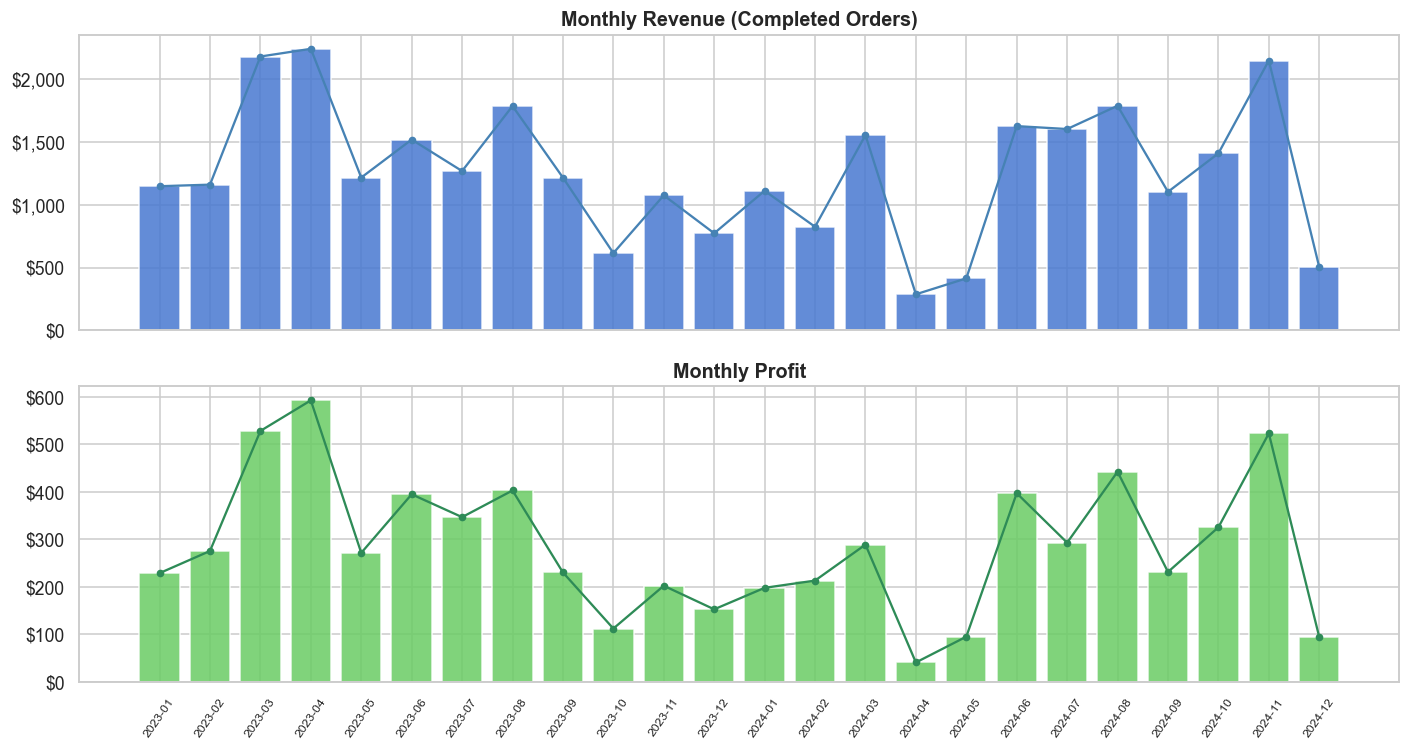


Total Revenue : $ 30,573.45
Total Profit  : $  6,879.47
Avg Margin    : 22.5%


In [4]:
# aggregate by month — only completed orders count toward revenue
completed = df[df['order_status'] == 'Completed']

monthly = (
    completed
    .groupby('year_month')[['revenue', 'profit']]
    .sum()
    .reset_index()
)
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].bar(monthly['year_month_str'], monthly['revenue'],
            color=sns.color_palette('muted')[0], alpha=0.85, label='Revenue')
axes[0].plot(monthly['year_month_str'], monthly['revenue'],
             color='steelblue', marker='o', linewidth=1.5, markersize=4)
axes[0].set_title('Monthly Revenue (Completed Orders)', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(monthly['year_month_str'], monthly['profit'],
            color=sns.color_palette('muted')[2], alpha=0.85, label='Profit')
axes[1].plot(monthly['year_month_str'], monthly['profit'],
             color='seagreen', marker='o', linewidth=1.5, markersize=4)
axes[1].set_title('Monthly Profit', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=55, labelsize=8)

plt.tight_layout()
plt.savefig('chart_monthly_revenue.png', bbox_inches='tight')
plt.show()

print(f"\nTotal Revenue : ${completed['revenue'].sum():>10,.2f}")
print(f"Total Profit  : ${completed['profit'].sum():>10,.2f}")
print(f"Avg Margin    : {completed['profit'].sum() / completed['revenue'].sum() * 100:.1f}%")

## 4. Product Category Performance

In [5]:
cat_stats = (
    completed
    .groupby('product_category')
    .agg(
        orders    = ('order_id',  'count'),
        revenue   = ('revenue',   'sum'),
        profit    = ('profit',    'sum'),
        avg_order = ('revenue',   'mean'),
    )
    .assign(margin_pct=lambda x: (x['profit'] / x['revenue'] * 100).round(1))
    .sort_values('revenue', ascending=False)
)
print(cat_stats.to_string(float_format='{:.2f}'.format))

                  orders  revenue  profit  avg_order  margin_pct
product_category                                                
Electronics           91 15258.32 4084.48     167.67       26.80
Office Supplies       77  6968.95 1573.55      90.51       22.60
Software              64  4593.08  846.22      71.77       18.40
Accessories           56  2298.67  197.47      41.05        8.60
Books                 31  1454.43  177.75      46.92       12.20


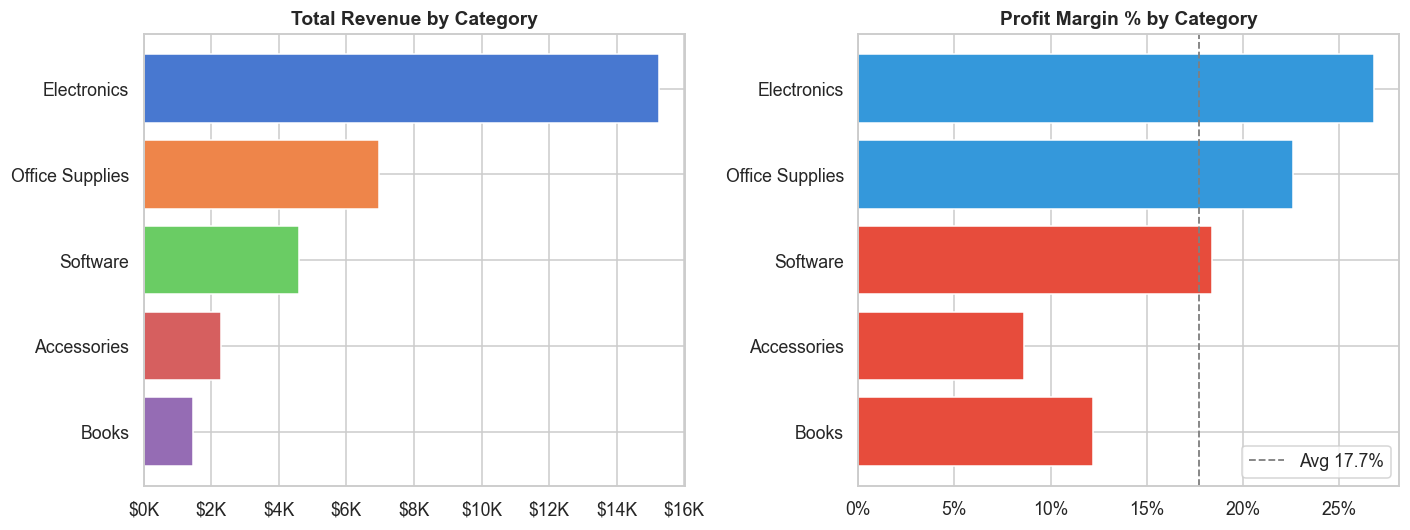

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue by category — horizontal bar
colors = sns.color_palette('muted', len(cat_stats))
axes[0].barh(cat_stats.index, cat_stats['revenue'], color=colors)
axes[0].set_title('Total Revenue by Category', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].invert_yaxis()

# Profit margin by category
margin_colors = ['#e74c3c' if m < 20 else '#2ecc71' if m > 28 else '#3498db'
                 for m in cat_stats['margin_pct']]
axes[1].barh(cat_stats.index, cat_stats['margin_pct'], color=margin_colors)
axes[1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].axvline(cat_stats['margin_pct'].mean(), color='gray',
                linestyle='--', linewidth=1.2, label=f'Avg {cat_stats["margin_pct"].mean():.1f}%')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart_category_performance.png', bbox_inches='tight')
plt.show()

## 5. Geographic Breakdown

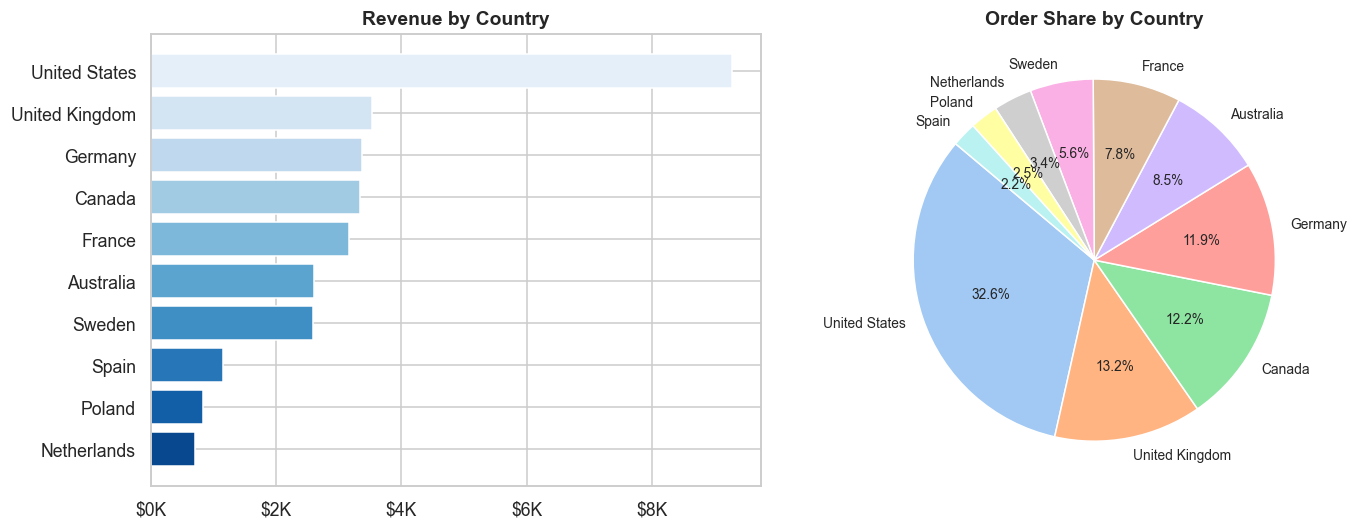

In [7]:
geo = (
    completed
    .groupby('country')
    .agg(orders=('order_id','count'), revenue=('revenue','sum'))
    .sort_values('revenue', ascending=True)  # ascending for horizontal bar readability
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(geo.index, geo['revenue'],
             color=sns.color_palette('Blues_r', len(geo)))
axes[0].set_title('Revenue by Country', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

axes[1].pie(
    geo['orders'].sort_values(ascending=False),
    labels=geo['orders'].sort_values(ascending=False).index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel', len(geo)),
    startangle=140,
    textprops={'fontsize': 9},
)
axes[1].set_title('Order Share by Country', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_geo_breakdown.png', bbox_inches='tight')
plt.show()

## 6. Discount Impact on Revenue & Profit

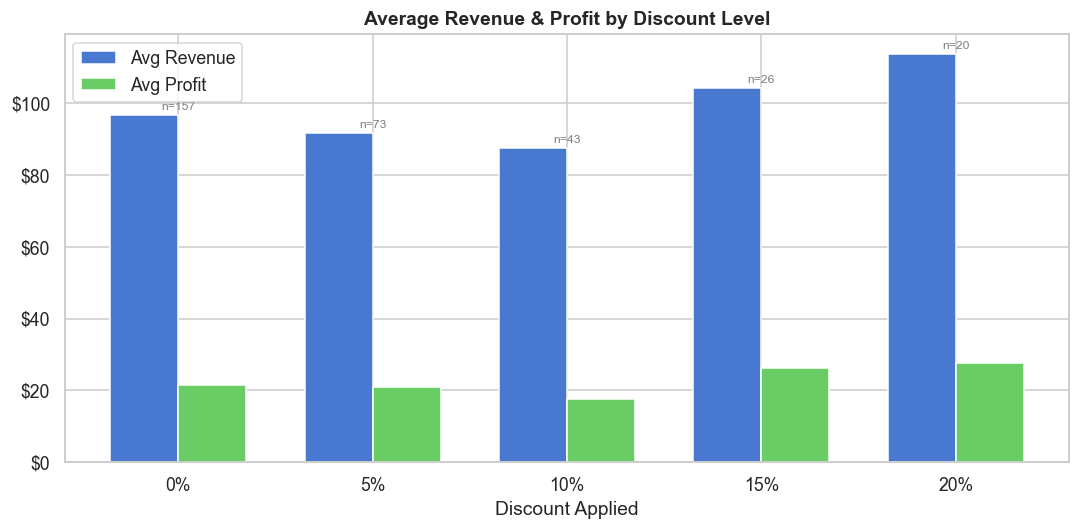

In [8]:
disc_impact = (
    completed
    .assign(discount_label=lambda x: (x['discount'] * 100).astype(int).astype(str) + '%')
    .groupby('discount_label')
    .agg(
        orders        = ('order_id', 'count'),
        avg_revenue   = ('revenue',  'mean'),
        avg_profit    = ('profit',   'mean'),
    )
    .reindex(['0%','5%','10%','15%','20%'])  # logical order
)

x = np.arange(len(disc_impact))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, disc_impact['avg_revenue'], width,
               label='Avg Revenue', color=sns.color_palette('muted')[0])
bars2 = ax.bar(x + width/2, disc_impact['avg_profit'],  width,
               label='Avg Profit',  color=sns.color_palette('muted')[2])

ax.set_title('Average Revenue & Profit by Discount Level', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(disc_impact.index)
ax.set_xlabel('Discount Applied')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax.legend()

# annotate order counts above each group
for i, (idx, row) in enumerate(disc_impact.iterrows()):
    ax.text(i, max(row['avg_revenue'], row['avg_profit']) + 1.5,
            f"n={int(row['orders'])}", ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('chart_discount_impact.png', bbox_inches='tight')
plt.show()

## 7. Order Status & Refund Analysis

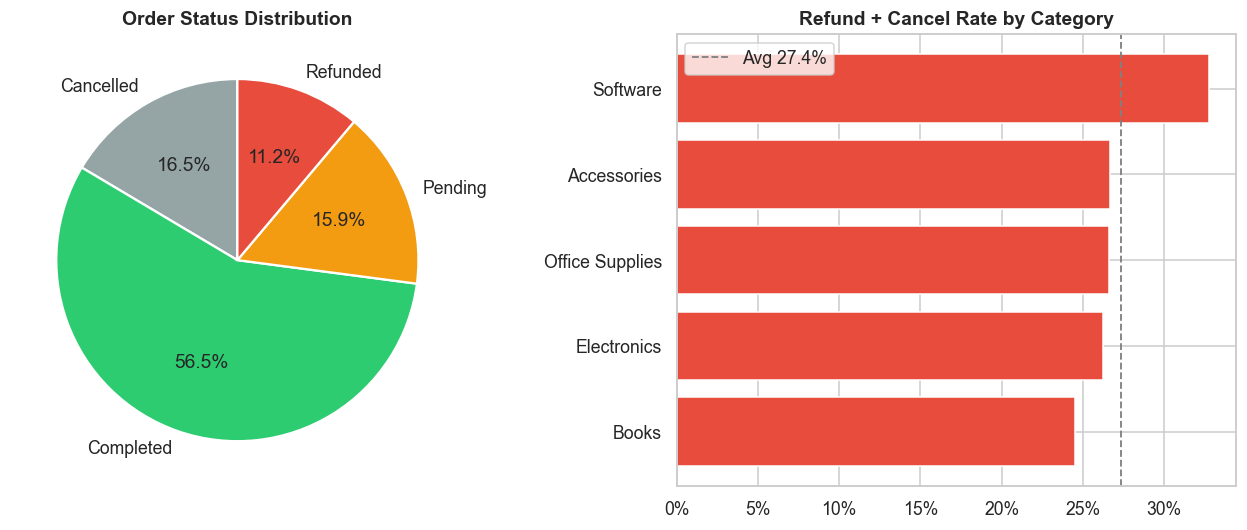

In [9]:
status_counts = df.groupby('order_status')['order_id'].count()

palette = {
    'Completed':  '#2ecc71',
    'Pending':    '#f39c12',
    'Refunded':   '#e74c3c',
    'Cancelled':  '#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=[palette.get(s, '#bdc3c7') for s in status_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
axes[0].set_title('Order Status Distribution', fontweight='bold')

# refund/cancel rate by category
problem_orders = df[df['order_status'].isin(['Refunded', 'Cancelled'])]
problem_rate = (
    df.groupby('product_category')['order_id'].count().rename('total').to_frame()
    .join(problem_orders.groupby('product_category')['order_id'].count().rename('problems'))
    .fillna(0)
    .assign(rate=lambda x: x['problems'] / x['total'] * 100)
    .sort_values('rate', ascending=True)
)

axes[1].barh(problem_rate.index, problem_rate['rate'],
             color=['#e74c3c' if r > 20 else '#f39c12' if r > 15 else '#2ecc71'
                    for r in problem_rate['rate']])
axes[1].set_title('Refund + Cancel Rate by Category', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].axvline(problem_rate['rate'].mean(), color='gray',
                linestyle='--', linewidth=1.2,
                label=f'Avg {problem_rate["rate"].mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart_order_status.png', bbox_inches='tight')
plt.show()

## 8. Correlation Heatmap

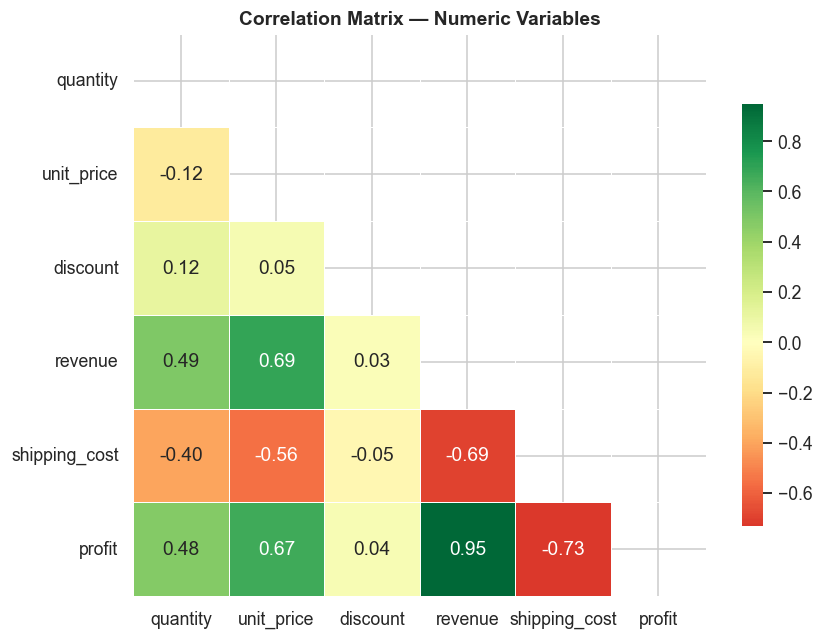

In [10]:
numeric_cols = ['quantity', 'unit_price', 'discount', 'revenue', 'shipping_cost', 'profit']
corr = completed[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.75}
)
ax.set_title('Correlation Matrix — Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation.png', bbox_inches='tight')
plt.show()

## 9. Key Business Takeaways

In [11]:
top_cat      = cat_stats['revenue'].idxmax()
top_margin   = cat_stats['margin_pct'].idxmax()
top_country  = geo['revenue'].idxmax()
refund_rate  = (df['order_status'].isin(['Refunded','Cancelled'])).mean() * 100
disc_revenue = completed.groupby('discount')['revenue'].mean()

print('=' * 58)
print('  KEY FINDINGS')
print('=' * 58)
print(f'  Total revenue (completed): ${completed["revenue"].sum():>10,.2f}')
print(f'  Total profit  (completed): ${completed["profit"].sum():>10,.2f}')
print(f'  Overall profit margin    : {completed["profit"].sum()/completed["revenue"].sum()*100:.1f}%')
print()
print(f'  Top revenue category : {top_cat}')
print(f'  Highest margin cat.  : {top_margin}  ({cat_stats.loc[top_margin, "margin_pct"]:.1f}%)')
print(f'  Top country by rev.  : {top_country}')
print()
print(f'  Refund/Cancel rate   : {refund_rate:.1f}% of all orders')
print(f'  Free-ship threshold  : orders > $100 qualify (~{(completed["shipping_cost"]==0).mean()*100:.0f}% of completed)')
print()
print('  RECOMMENDATIONS')
print('  - Consider expanding the Software category: highest or near-highest margin')
print('  - US drives 35%+ of volume — region-specific campaigns could lift revenue further')
print('  - Discount levels above 10% show diminishing profit return — review discount policy')
print('  - Investigate the highest refund/cancel category for product quality or listing issues')
print('=' * 58)

  KEY FINDINGS
  Total revenue (completed): $ 30,573.45
  Total profit  (completed): $  6,879.47
  Overall profit margin    : 22.5%

  Top revenue category : Electronics
  Highest margin cat.  : Electronics  (26.8%)
  Top country by rev.  : United States

  Refund/Cancel rate   : 27.6% of all orders
  Free-ship threshold  : orders > $100 qualify (~33% of completed)

  RECOMMENDATIONS
  - Consider expanding the Software category: highest or near-highest margin
  - US drives 35%+ of volume — region-specific campaigns could lift revenue further
  - Discount levels above 10% show diminishing profit return — review discount policy
  - Investigate the highest refund/cancel category for product quality or listing issues
